In [1]:
from utils.data import ProteinDataset, QueryHomologyDataset
import torch as pt
import numpy as np
from utils.data import ProteinDataset, QueryHomologyDataset


print('loading data')
# (seq_list, lab_list)
data = pt.load(f'./data/seq_shorter_than_1300_sorted.pt', weights_only=False)
datalib = ProteinDataset(data)
lib_map = np.arange(len(datalib), dtype=np.int64)
print('number of proteins:', len(lib_map))

pdb2idx = {data[1][i]: i for i in range(len(data[1]))} 
query_homo_data = QueryHomologyDataset(datalib, './data/tmalign.out', pdb2idx)
print('Query_i homology_ij pair num:', len(query_homo_data))

loading data
number of proteins: 106663
Query_i homology_ij pair num: 30646


In [15]:
print(len(datalib[0]))

2


In [13]:
query_idx_list = [g[0] for g in query_homo_data]
query_idx_dict = set(query_idx_list)
lib_not_in_query_home_map = np.array(
        [i for i in range(len(datalib)) if i not in query_idx_dict],
        dtype=np.int64,
    )
print(len(lib_not_in_query_home_map))

76017


In [3]:
candidate_num_dict = {}
for i in range(30646):
    c_num = len(query_homo_data[i][1])
    if c_num in candidate_num_dict:
        candidate_num_dict[c_num] += 1
    else:
        candidate_num_dict[c_num] = 1
candidate_num_list = [candidate_num_dict[c_num] for c_num in candidate_num_dict.keys()]

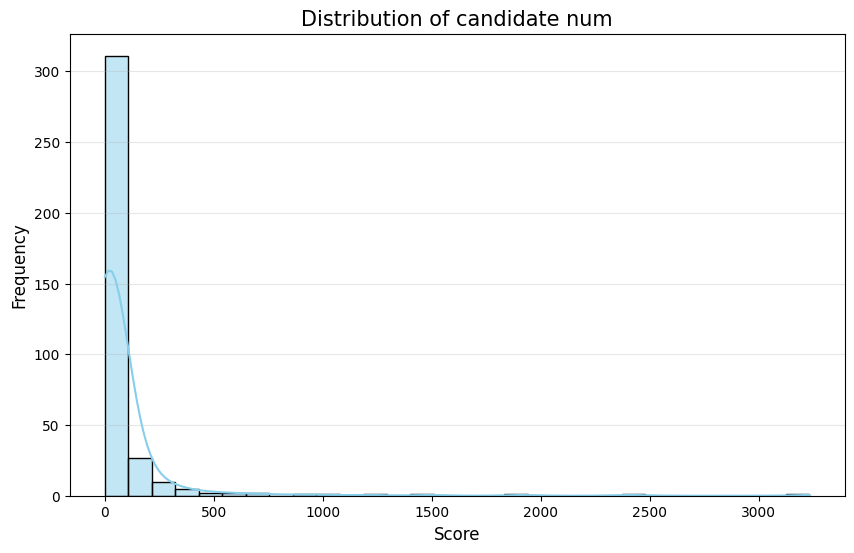

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.histplot(candidate_num_list, kde=True, color='skyblue', bins=30)

# 添加装饰
plt.title('Distribution of candidate num', fontsize=15)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# 显示图表
plt.show()

In [2]:
import os
from pathlib import Path
from utils.tools import run_tmalign
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed


def make_pdb_path(pdb_root, pdb_name: str) -> Path:
    return Path(pdb_root) / pdb_name[1:3] / f"{pdb_name}.pdb"

def generate_tasks(
    database,
    query_homo,
    pdb_root: str = "../../data/pdb",
    tmalign_path: str = "./TMalign",
    reference: int = 1,
):
    # 生成所有 (q_file, c_file, tmalign_path, reference) 任务
    pdb_root = Path(pdb_root)
    tmalign_path = Path(tmalign_path).resolve()
    if not tmalign_path.is_file():
        raise FileNotFoundError(f"TMalign binary not found: {tmalign_path}")
    for i in range(30):
        for j in range(30):
            if j != i:
                q_idx = query_homo[i][0]
                q_name = database[q_idx][-1]
                q_file = make_pdb_path(pdb_root, q_name)
                if not q_file.is_file():
                    raise FileNotFoundError(f"Query PDB file not found: {q_file}")
                for k in query_homo[i][1]:
                    c_name = database[int(k)][-1]
                    c_file = make_pdb_path(pdb_root, c_name)
                    if not c_file.is_file():
                        raise FileNotFoundError(f"Candidate PDB file not found: {c_file}")
                    yield (i, int(k), q_file, c_file, tmalign_path, reference)

def calculate_remote_homology_score(
    database, query_homo, 
    pdb_root: str = "../../data/pdb",
    tmalign_path: str = "./TMalign",
    reference: int = 1,
    num_workers: int = None,
):
    """
    并行计算 remote homology score
    这里使用 ThreadPoolExecutor,而不是 multiprocessing.Pool:
    - 真正耗时的是外部 TMalign 进程
    - 线程只负责并发调度 subprocess.run
    - 避免在已初始化 CUDA 的训练进程里再 fork 多进程
    """
    tasks = list(
        generate_tasks(
            database=database, query_homo=query_homo,
            pdb_root=pdb_root, tmalign_path=tmalign_path, reference=reference,
        )
    )
    N = len(query_homo)
    if len(tasks) == 0:
        raise ValueError("No TM-align tasks were generated.")
    if num_workers is None:
        cpu_count = os.cpu_count() or 1
        num_workers = max(1, min(len(tasks), cpu_count // 2 if cpu_count > 1 else 1))
    
    results_dict = {i: [] for i in range(N)}
    avg_topk_score = 0.0
    success_cnt = 0
    error_messages = []
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(run_tmalign, task) for task in tasks]
        for future in tqdm(as_completed(futures), total=len(futures), desc="TM-align", leave=False,):
            try:
                q_idx, c_idx, score = future.result()
                results_dict[q_idx].append({'c_idx': c_idx, 'score': score})
                avg_topk_score += score
                success_cnt += 1
            except Exception as e:
                error_messages.append(str(e))
    if success_cnt == 0:
        raise RuntimeError("All TM-align tasks failed.\n" + ("\n\nFirst error:\n" + error_messages[0] if error_messages else ""))
    if error_messages:
        print(f"[Warning] {len(error_messages)} TM-align tasks failed. First error:\n{error_messages[0]}")
    avg_topk_score /= success_cnt

    sorted_results = {}
    avg_top1_score = 0.0
    valid_queries = 0
    for q_idx in range(N):
        c_list = results_dict[q_idx]
        c_list.sort(key=lambda x: x['score'], reverse=True)
        sorted_results[q_idx] = c_list
        if len(c_list) > 0:
            avg_top1_score += c_list[0]['score']
            valid_queries += 1
    if valid_queries > 0:
        avg_top1_score /= valid_queries
    
    return sorted_results, avg_top1_score, avg_topk_score

sorted_results, avg_top1_score, avg_topk_score = calculate_remote_homology_score(datalib, query_homo_data,)
print(avg_top1_score, avg_topk_score)

0.19356233333333334 0.12909742366412646
